In [1400]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings

In [1401]:
df = pd.read_csv('SA_Aqar.csv')
df
#df.info()

#df['city'].value_counts()
#df['front'].value_counts()
#df['district'].value_counts()
#df.info()


top_20 = df.groupby('district')['price'].sum().sort_values(ascending=False).head(100)
df['district'] = df['district'].apply(lambda x: x if x in top_20 else 'Other')

#df['district']


In [1402]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

In [1403]:
y = df['price']

X_raw = df.drop(columns=['price', 'details'])

X = pd.get_dummies(X_raw, columns=['city', 'front','district'], drop_first=True) #city = boolean , district = boolean , front = 10

feature_names = X.columns

In [1404]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")


Train set: 2780 samples
Test set:  696 samples


In [1405]:
model = LinearRegression()
model.fit(X, y)

print("Model trained successfully!")

Model trained successfully!


In [1406]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("\nTrain Performance:")
print(f"  R²  = {r2_score(y_train, y_pred_train):.4f}")
print(f"  MSE = {mean_squared_error(y_train, y_pred_train):.2f}")
print(f"  MAE = {mean_absolute_error(y_train, y_pred_train):.2f}")


print("\nTest Performance:")
print(f"  R²  = {r2_score(y_test, y_pred_test):.4f}")
print(f"  MSE = {mean_squared_error(y_test, y_pred_test):.2f}")
print(f"  MAE = {mean_absolute_error(y_test, y_pred_test):.2f}")
print("\n")


Train Performance:
  R²  = 0.7889
  MSE = 242634718.58
  MAE = 9704.60

Test Performance:
  R²  = 0.7950
  MSE = 243553315.32
  MAE = 10727.42




In [1407]:
print("Feature Coefficients (sorted by impact):\n")
sorted_features = sorted(zip(feature_names, model.coef_), key=lambda x: abs(x[1]), reverse=True)
for name, coef in sorted_features:
    sign = "+" if coef > 0 else ""
    print(f"  {name:15s} → {sign}{coef:.4f}")
print(f"  {'Intercept':15s} → {model.intercept_:.4f}")

print("\nInterpretation:")
print("  - Positive coefficient → feature increases price")
print("  - Negative coefficient → feature decreases price")


Feature Coefficients (sorted by impact):

  district_   حي الفرسان  → -62560.1344
  district_   حي الحزام الاخضر  → +61733.9711
  district_   حي الحزم  → -61500.5716
  district_   حي العريجاء الغربية  → -56308.9719
  district_   حي طويق  → -55111.8574
  district_   حي الاسكان  → -52894.4737
  district_   حي الشرق  → -52700.4860
  district_   حي بدر  → -52373.5227
  district_   حي ضاحية الملك فهد  → -50901.7607
  district_   حي الزهراء  → +50521.3078
  district_   حي الزمرد  → -47112.3925
  district_   حي الرمال  → -47096.4237
  district_   حي المرسلات  → +46464.7044
  district_   حي ظهرة لبن  → -40544.2469
  district_   حي بريمان  → -40492.7633
  district_   حي المدينة الرياضية  → -40447.7583
  district_   حي النموذجية  → +40298.9715
  district_   حي طيبة  → -39372.3907
  district_   حي المهدية  → -38638.3943
  district_   حي ام الحمام الغربي  → -36595.2799
  district_   حي المنتزه  → +35754.8604
  district_   حي الجوهرة  → -35505.0929
  district_   حي الشعلة  → -35301.4903
  district_

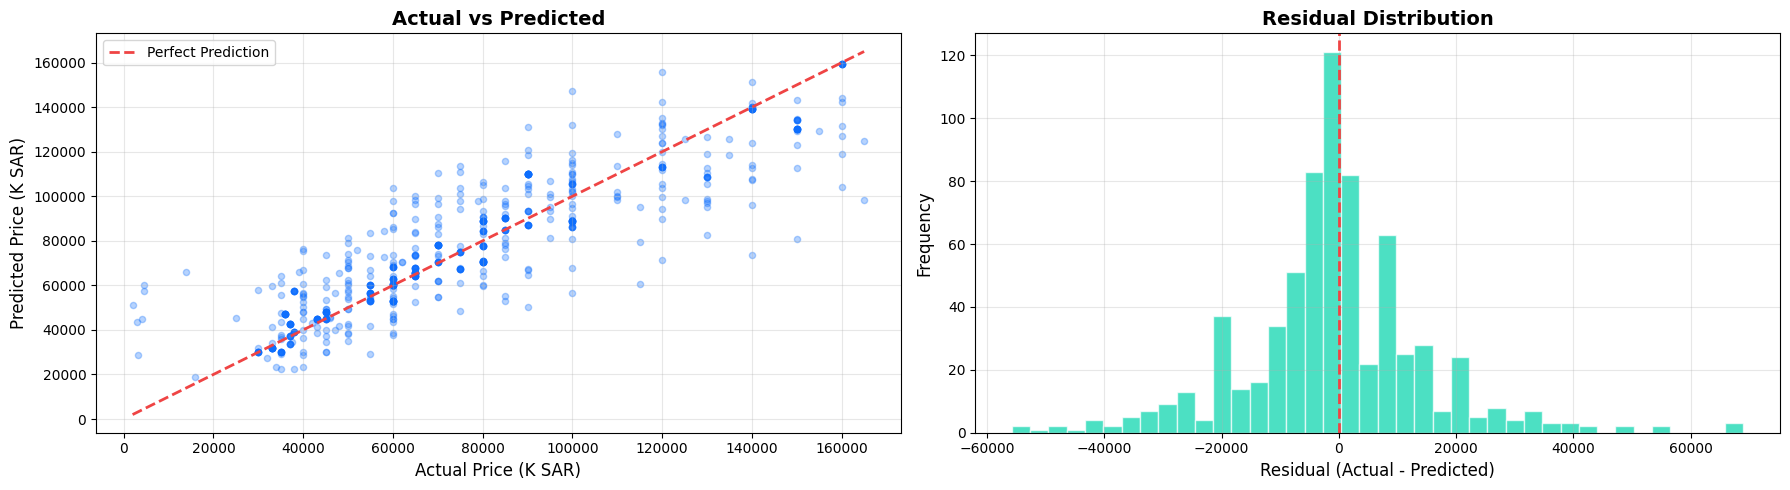

In [1408]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

ax1 = axes[0]
ax1.scatter(y_test, y_pred_test, alpha=0.3, color="#0D6EFD", s=20)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="#EF4444", linewidth=2, linestyle="--", label="Perfect Prediction")
ax1.set_xlabel("Actual Price (K SAR)", fontsize=12)
ax1.set_ylabel("Predicted Price (K SAR)", fontsize=12)
ax1.set_title("Actual vs Predicted", fontsize=14, fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
residuals_test = y_test - y_pred_test
ax2.hist(residuals_test, bins=40, color="#00D4AA", alpha=0.7, edgecolor="white")
ax2.axvline(x=0, color="#EF4444", linewidth=2, linestyle="--")
ax2.set_xlabel("Residual (Actual - Predicted)", fontsize=12)
ax2.set_ylabel("Frequency", fontsize=12)
ax2.set_title("Residual Distribution", fontsize=14, fontweight="bold")
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

In [1409]:
new_data = pd.DataFrame([{
    "city_ جدة": 1,
    "district_   حي الربوة ": 1,
    "front_شمال غربي": 1,
    "size": 300,
    "property_age": 5,
    "bedrooms": 5,
    "bathrooms": 4,
    "livingrooms": 2,
    "kitchen": 1,
    "garage": 1,
    "driver_room": 1,
    "maid_room": 1,
    "furnished": 0,
    "ac": 1,
    "roof": 0,
    "pool": 1,
    "frontyard": 1,
    "basement": 0,
    "duplex": 0,
    "stairs": 1,
    "elevator": 0,
    "fireplace": 0
}])

new_data = pd.get_dummies(new_data)

new_data = new_data.reindex(columns=feature_names, fill_value=0)
N = 12
prediction = model.predict(new_data)
print(f"{round(prediction[0],2)} SAR")


108574.61 SAR


In [1410]:
prediction2 =model.predict(X_test.iloc[[27]])
print(f"Predicted value: {round(prediction2[0])} SAR")
print(f"Actual value: {round(y_test.iloc[27])} SAR")


Predicted value: 44895 SAR
Actual value: 43000 SAR
